# ERP Trial-Split Augmentation

This notebook explores trial-based data augmentation on labeled ERP images (only classes `> 0`, merged the same way as in `model_validate.ipynb`).

Workflow:
1. Build a reference image with the standard pipeline (`sort -> z-score -> low-pass -> resize`).
2. Split raw trials before processing:
   - random balanced assignment (`k=2,3,4`)
   - sorted by `sort_variable` and then assigned by modulo (`k=2,3,4`)
3. Plot each ERP image with its own asymmetric colorbar:
   - `vmin = 1% quantile`, `vmax = 99% quantile` from the downscaled matrix
   - clip values to `[vmin, vmax]`
   - keep `0` at white in the diverging colormap
4. Test Augmentor operations with a strict before/after comparison on a single randomly selected ERP image per run.


In [1]:
versioninfo()


Julia Version 1.12.3
Commit 966d0af0fdf (2025-12-15 11:20 UTC)
Build Info:
  Official https://julialang.org release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 16 × AMD Ryzen 7 7800X3D 8-Core Processor
  WORD_SIZE: 64
  LLVM: libLLVM-18.1.7 (ORCJIT, znver4)
  GC: Built with stock GC
Threads: 16 default, 1 interactive, 16 GC (on 16 virtual cores)
Environment:
  JULIA_NUM_THREADS = 16


In [2]:
import Pkg

# Make notebook startup more stable in VS Code notebooks.
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = "0"
ENV["JULIA_NUM_PRECOMPILE_TASKS"] = "1"

Pkg.activate(".")

using CSV, DataFrames, HDF5, Statistics, Random, Printf
using CairoMakie
using ImageFiltering: imfilter
using Images: imresize, Gray, N0f8, Colorant

# Load Augmentor from an isolated environment to avoid dependency conflicts with Makie.
const AUGMENTOR_ENV = joinpath(pwd(), ".augmentor_env")
if !(AUGMENTOR_ENV in LOAD_PATH)
    push!(LOAD_PATH, AUGMENTOR_ENV)
end

try
    @eval using Augmentor
catch err
    println("Augmentor not available in $(AUGMENTOR_ENV). Installing now...")
    Pkg.activate(AUGMENTOR_ENV)
    Pkg.add("Augmentor")
    Pkg.precompile()
    Pkg.activate(".")
    if !(AUGMENTOR_ENV in LOAD_PATH)
        push!(LOAD_PATH, AUGMENTOR_ENV)
    end
    @eval using Augmentor
end

include(joinpath(pwd(), "..", "utils", "erp_image_utils.jl"))
using .ERPImageUtils: gaussian_kernel, zscore_timepoints, clipped_color_stats_filter_row

const SAMPLING_RATE = 512
const PRE_STIM_S = 0.5
const TIME_ZERO_IDX = Int(round(PRE_STIM_S * SAMPLING_RATE)) + 1
const TARGET_SIZE = (64, 64)
const LOWPASS_SIGMA = 75.0f0
const LOWPASS_KERNEL_SIZE = (21, 21)
const FILTER_BORDER = "reflect"

const RESULTS_CSV_PATHS = [
    joinpath(pwd(), "results", "project-14-at-2026-02-15-23-09-f5225e5c.csv"),
    joinpath(pwd(), "results", "project-15-at-2026-02-18-19-35-828515fe.csv"),
]
const H5_PATH = joinpath(pwd(), "data_fixations.hdf5")
const EVENTS_CSV_PATH = joinpath(pwd(), "events.csv")

for p in vcat(RESULTS_CSV_PATHS, [H5_PATH, EVENTS_CSV_PATH])
    @assert isfile(p) "File not found: $p"
end


  Activating project at `~/Dokumente/BA2/notebooks/model_test`


In [3]:
function load_erps_from_h5(path::AbstractString)
    return h5open(path, "r") do f
        candidates = ["erps", "/erps", "data", "/data/data_fixations.hdf5", "data/data_fixations.hdf5"]
        for key in candidates
            if haskey(f, key)
                obj = f[key]
                if obj isa HDF5.Dataset
                    return read(obj)
                end
            end
        end

        function first_dataset(g)
            for k in keys(g)
                obj = g[k]
                if obj isa HDF5.Dataset
                    return read(obj)
                elseif obj isa HDF5.Group
                    x = first_dataset(obj)
                    x === nothing || return x
                end
            end
            return nothing
        end

        x = first_dataset(f)
        x === nothing && error("No dataset found in HDF5 file: $path")
        return x
    end
end

function load_and_merge_label_sources(paths::Vector{String})
    dfs = DataFrame[]
    for p in paths
        df = CSV.read(p, DataFrame)
        df.source_csv = fill(basename(p), nrow(df))
        push!(dfs, df)
    end

    labels_all = vcat(dfs...; cols = :union)

    if :image in names(labels_all)
        updated_at_str = :updated_at in names(labels_all) ? string.(coalesce.(labels_all.updated_at, "")) : fill("", nrow(labels_all))
        created_at_str = :created_at in names(labels_all) ? string.(coalesce.(labels_all.created_at, "")) : fill("", nrow(labels_all))
        labels_all.updated_at_str = updated_at_str
        labels_all.created_at_str = created_at_str

        # Keep newest annotation per image.
        sort!(labels_all, [:image, :updated_at_str, :created_at_str], rev = [false, true, true])
        labels_merged = unique(labels_all, :image)
    else
        labels_merged = labels_all
    end

    return labels_all, labels_merged
end

parse_class_id(v) = begin
    t = tryparse(Int, strip(string(v)))
    t === nothing ? missing : t
end

function has_required_metadata(row)
    cols = propertynames(row)
    if !(:channel in cols && :sort_variable in cols)
        return false
    end
    return !ismissing(row.channel) && !ismissing(row.sort_variable)
end

erps = load_erps_from_h5(H5_PATH)
events = CSV.read(EVENTS_CSV_PATH, DataFrame)
labels_all_df, labels_merged_df = load_and_merge_label_sources(RESULTS_CSV_PATHS)

labels_merged_df.erp_class_id = [parse_class_id(v) for v in labels_merged_df.erp_class]
pattern_mask = map(v -> !ismissing(v) && v > 0, labels_merged_df.erp_class_id)
meta_mask = map(has_required_metadata, eachrow(labels_merged_df))
labels_labeled_df = copy(labels_merged_df[pattern_mask .& meta_mask, :])

labels_labeled_df.channel_int = Int.(labels_labeled_df.channel)
labels_labeled_df.sort_var_symbol = Symbol.(String.(labels_labeled_df.sort_variable))

println("ERP tensor size: ", size(erps), " (channel, time, trial)")
println("Events rows: ", nrow(events))
println("Labels imported (all): ", nrow(labels_all_df))
println("Labels merged unique by image: ", nrow(labels_merged_df))
println("Labels used for augmentation (class > 0): ", nrow(labels_labeled_df))
println("Class distribution (class > 0):")
show(combine(groupby(labels_labeled_df, :erp_class_id), nrow => :count), allrows = true, allcols = true)
println()


ERP tensor size: (128, 769, 2508) (channel, time, trial)
Events rows: 2508
Labels imported (all): 500
Labels merged unique by image: 500
Labels used for augmentation (class > 0): 48
Class distribution (class > 0):
5×2 DataFrame
 Row │ erp_class_id  count 
     │ Int64         Int64 
─────┼─────────────────────
   1 │            1     36
   2 │            3      2
   3 │            4      6
   4 │            5      3
   5 │            6      1


In [8]:
function sortvalues_from(df::DataFrame, col::Symbol)
    v = df[!, col]
    if eltype(v) <: Number
        return Float64.(v)
    end
    return collect(v)
end

function extract_channel_trials(erps, events::DataFrame, channel::Int; time_zero_idx::Int = TIME_ZERO_IDX)
    @assert 1 <= channel <= size(erps, 1) "channel out of range"
    data = Float32.(erps[channel, time_zero_idx:end, :])
    n = min(size(data, 2), nrow(events))
    return data[:, 1:n], events[1:n, :]
end

function sort_zscore_to_trials_time_image(data_time_trials::AbstractMatrix, events_trials::DataFrame, sort_col::Symbol)
    @assert size(data_time_trials, 2) == nrow(events_trials) "trial count mismatch between matrix and events"
    @assert sort_col in propertynames(events_trials) "sort column not found: $(sort_col)"

    sortvals = sortvalues_from(events_trials, sort_col)
    order = sortperm(sortvals)
    data_sorted = data_time_trials[:, order]

    data_z = zscore_timepoints(data_sorted)
    return Float32.(permutedims(data_z, (2, 1)))
end

function lowpass_resize_trials_time_image(img_trials_time::AbstractMatrix;
    target_size::Tuple{Int, Int} = TARGET_SIZE,
    low_pass_sigma::Float32 = LOWPASS_SIGMA,
    lowpass_kernel_size::Tuple{Int, Int} = LOWPASS_KERNEL_SIZE,
    filter_border::String = FILTER_BORDER)

    kernel = gaussian_kernel(low_pass_sigma, size(img_trials_time), target_size, lowpass_kernel_size)
    img_lowpass = Float32.(imfilter(Float32.(img_trials_time), kernel, filter_border))
    return Float32.(imresize(img_lowpass, target_size))
end

function sanitize_nonfinite(data::AbstractMatrix)
    out = Float32.(data)
    bad_mask = .!isfinite.(out)
    n_bad = count(bad_mask)
    if n_bad > 0
        out[bad_mask] .= 0f0
    end
    return out, n_bad
end

function apply_augmentor_operation(img_trials_time::AbstractMatrix, op_name::String, op)
    source = Float32.(img_trials_time)

    # ColorJitter expects color-like intensity input, so map to Gray in [0,1] first.
    if op_name == "ColorJitter"
        source_gray = Gray{N0f8}.(clamp.(source, 0f0, 1f0))
        out = Array(augment(source_gray, op))
        cleaned, _ = sanitize_nonfinite(Float32.(Gray.(out)))
        return cleaned
    end

    out = Array(augment(source, op))
    out_f = if eltype(out) <: Colorant
        Float32.(Gray.(out))
    else
        Float32.(out)
    end

    cleaned, _ = sanitize_nonfinite(out_f)
    return cleaned
end

function preprocess_erp_subset(data_time_trials::AbstractMatrix, events_trials::DataFrame, sort_col::Symbol;
    target_size::Tuple{Int, Int} = TARGET_SIZE,
    low_pass_sigma::Float32 = LOWPASS_SIGMA,
    lowpass_kernel_size::Tuple{Int, Int} = LOWPASS_KERNEL_SIZE,
    filter_border::String = FILTER_BORDER,
    augment_name::Union{Nothing, String} = nothing,
    augment_op = nothing)

    img_trials_time = sort_zscore_to_trials_time_image(data_time_trials, events_trials, sort_col)

    # Augmentation is inserted after sort+zscore and before low-pass+resize.
    if augment_op !== nothing
        @assert augment_name !== nothing "augment_name must be set when augment_op is provided"
        img_trials_time = apply_augmentor_operation(img_trials_time, augment_name, augment_op)
    end

    return lowpass_resize_trials_time_image(img_trials_time;
        target_size = target_size,
        low_pass_sigma = low_pass_sigma,
        lowpass_kernel_size = lowpass_kernel_size,
        filter_border = filter_border)
end

function split_indices_random(n::Int, k::Int, rng::AbstractRNG)
    n == 0 && return [Int[]]
    k_eff = min(max(k, 1), n)
    groups = [Int[] for _ in 1:k_eff]

    for (i, idx) in enumerate(randperm(rng, n))
        push!(groups[((i - 1) % k_eff) + 1], idx)
    end

    return groups
end

function split_indices_sorted_modulo(events_trials::DataFrame, sort_col::Symbol, k::Int)
    n = nrow(events_trials)
    n == 0 && return [Int[]]
    k_eff = min(max(k, 1), n)

    sortvals = sortvalues_from(events_trials, sort_col)
    order = sortperm(sortvals)

    groups = [Int[] for _ in 1:k_eff]
    for (i, idx) in enumerate(order)
        push!(groups[((i - 1) % k_eff) + 1], idx)
    end

    return groups
end

function axis_ticks(n::Int)
    mid = Int(cld(n, 2))
    vals = [1, mid, n]
    labels = string.(vals)
    return vals, labels
end

function image_id_from_row(row)
    cols = propertynames(row)
    if :image_file in cols && !ismissing(row.image_file)
        return String(row.image_file)
    end
    if :image in cols && !ismissing(row.image)
        return String(row.image)
    end
    return "unknown_image"
end

function preprocess_by_indices(data_full::AbstractMatrix, events_full::DataFrame, sort_col::Symbol, idxs::Vector{Int};
    augment_name::Union{Nothing, String} = nothing,
    augment_op = nothing)

    data_part = data_full[:, idxs]
    events_part = events_full[idxs, :]
    return preprocess_erp_subset(data_part, events_part, sort_col;
        augment_name = augment_name,
        augment_op = augment_op)
end

function row_header(split_mode::Symbol, k::Int)
    if split_mode == :random
        return "Random split k=$(k)"
    elseif split_mode == :sorted_modulo
        return "Sorted-modulo split k=$(k)"
    else
        error("Unsupported split mode: $(split_mode)")
    end
end

function plot_trial_split_overview(erps, events::DataFrame, channel::Int, sort_col::Symbol;
    class_id::Int,
    image_id::String,
    split_mode::Symbol = :random,
    k_values::Vector{Int} = [2, 3, 4],
    q_low::Float64 = 0.01,
    q_high::Float64 = 0.99,
    target_size::Tuple{Int, Int} = TARGET_SIZE,
    seed::Int = 20260220)

    data_full, events_full = extract_channel_trials(erps, events, channel)
    n_trials = size(data_full, 2)

    row_specs = NamedTuple[]
    push!(row_specs, (k = 1, groups = [collect(1:n_trials)], row_label = "Reference"))

    rng = MersenneTwister(seed + 17 * channel + 101 * class_id)
    for k in k_values
        groups = split_mode == :random ?
            split_indices_random(n_trials, k, rng) :
            split_indices_sorted_modulo(events_full, sort_col, k)
        push!(row_specs, (k = length(groups), groups = groups, row_label = row_header(split_mode, k)))
    end

    max_k = maximum(vcat(1, [r.k for r in row_specs]))
    fig = Figure(size = (390 * max_k, 315 * length(row_specs) + 120), figure_padding = 24)

    mode_text = split_mode == :random ? "random trial assignment" : "sorted modulo assignment"
    header = "ERP trial split augmentation | $(mode_text) | ch$(lpad(string(channel), 3, '0')) | $(sort_col) | class=$(class_id)"
    Label(fig[0, 1:(2 * max_k)], header; fontsize = 20, tellwidth = false)

    for (row_i, row) in enumerate(row_specs)
        for part_i in 1:row.k
            idxs = row.groups[part_i]
            img = preprocess_by_indices(data_full, events_full, sort_col, idxs)

            # Asymmetric clipping from the downscaled matrix, with white fixed at 0.
            clipped, crange, tick_vals, tick_labels, cmap = clipped_color_stats_filter_row(img; q_low = q_low, q_high = q_high)

            xtick_vals, xtick_labels = axis_ticks(size(img, 2))
            ytick_vals, ytick_labels = axis_ticks(size(img, 1))

            img_col = 2 * part_i - 1
            cb_col = 2 * part_i

            title_text = row.k == 1 ?
                "Reference | n=$(length(idxs)) trials" :
                "$(row.row_label) | part $(part_i)/$(row.k) | n=$(length(idxs))"

            ax = Axis(fig[row_i, img_col];
                title = title_text,
                titlesize = 15,
                titlegap = 6,
                aspect = DataAspect(),
                xticks = (xtick_vals, xtick_labels),
                yticks = (ytick_vals, ytick_labels),
                xticklabelsize = 12,
                yticklabelsize = 12,
                xlabel = "time",
                ylabel = "trials",
                xlabelsize = 14,
                ylabelsize = 14,
            )

            hm = heatmap!(ax, permutedims(clipped, (2, 1)); colormap = cmap, colorrange = crange)
            Colorbar(fig[row_i, cb_col], hm; width = 16, ticklabelsize = 11, ticks = (tick_vals, tick_labels))

            colsize!(fig.layout, img_col, Fixed(290))
            colsize!(fig.layout, cb_col, Fixed(52))
        end
    end

    Label(fig[length(row_specs) + 1, 1:(2 * max_k)], "image=$(image_id)"; fontsize = 11, tellwidth = false)

    rowgap!(fig.layout, 14)
    colgap!(fig.layout, 10)
    resize_to_layout!(fig)

    return fig
end

function build_augmentor_operation_specs(img_trials_time::AbstractMatrix)
    h, w = size(img_trials_time)

    resize_h = max(16, round(Int, 0.7 * h))
    resize_w = max(16, round(Int, 0.7 * w))
    crop_h = max(16, round(Int, 0.75 * h))
    crop_w = max(16, round(Int, 0.75 * w))

    return [
        (name = "FlipX", description = "horizontal flip", op = FlipX()),
        (name = "Rotate", description = "rotation by +5°", op = Rotate(5.0)),
        (name = "ShearX", description = "x-shear by +12°", op = ShearX(12.0)),
        (name = "Scale", description = "uniform scale x1.15", op = Scale(1.15)),
        (name = "Resize", description = "resize to 70% of original", op = Resize(resize_h, resize_w)),
        (name = "Zoom", description = "zoom x1.20", op = Zoom(1.20)),
        (name = "ElasticDistortion", description = "grid warp (16,16,0.25)", op = ElasticDistortion(16, 16, 0.25)),
        (name = "ColorJitter", description = "brightness/contrast jitter", op = ColorJitter(0.15, 0.15)),
        (name = "GaussianBlur", description = "blur kernel 5, sigma 1.0", op = GaussianBlur(5, 1.0)),
        (name = "Crop", description = "top-left crop (75% x 75%)", op = Crop(1:crop_h, 1:crop_w)),
        (name = "CropSize", description = "center crop by fixed size", op = CropSize(crop_h, crop_w)),
        (name = "CropRatio", description = "center crop to square ratio", op = CropRatio(1.0)),
    ]
end

function plot_before_after_augmentation(before_img::AbstractMatrix, after_img::AbstractMatrix;
    header::String,
    right_title::String,
    q_low::Float64 = 0.01,
    q_high::Float64 = 0.99)

    fig = Figure(size = (930, 430), figure_padding = 24)
    Label(fig[0, 1:4], header; fontsize = 19, tellwidth = false)

    panels = [
        (img = before_img, title = "No augmentation"),
        (img = after_img, title = right_title),
    ]

    for (j, panel) in enumerate(panels)
        clipped, crange, tick_vals, tick_labels, cmap = clipped_color_stats_filter_row(panel.img; q_low = q_low, q_high = q_high)
        xtick_vals, xtick_labels = axis_ticks(size(panel.img, 2))
        ytick_vals, ytick_labels = axis_ticks(size(panel.img, 1))

        img_col = 2 * j - 1
        cb_col = 2 * j

        ax = Axis(fig[1, img_col];
            title = panel.title,
            titlesize = 15,
            titlegap = 6,
            aspect = DataAspect(),
            xticks = (xtick_vals, xtick_labels),
            yticks = (ytick_vals, ytick_labels),
            xticklabelsize = 12,
            yticklabelsize = 12,
            xlabel = "time",
            ylabel = "trials",
            xlabelsize = 14,
            ylabelsize = 14,
        )

        hm = heatmap!(ax, permutedims(clipped, (2, 1)); colormap = cmap, colorrange = crange)
        Colorbar(fig[1, cb_col], hm; width = 16, ticklabelsize = 11, ticks = (tick_vals, tick_labels))

        colsize!(fig.layout, img_col, Fixed(350))
        colsize!(fig.layout, cb_col, Fixed(52))
    end

    rowgap!(fig.layout, 12)
    colgap!(fig.layout, 10)
    resize_to_layout!(fig)

    return fig
end


plot_before_after_augmentation (generic function with 1 method)

## Random Trial Splits (k = 2, 3, 4)

Trials are first split in the **raw signal** by random balanced assignment. Each subset is then processed with the standard ERP pipeline.


Selected example for plotting:
  ch031 | sac_amplitude | class=4 | erp_additional_093_ch031_sac_amplitude.png


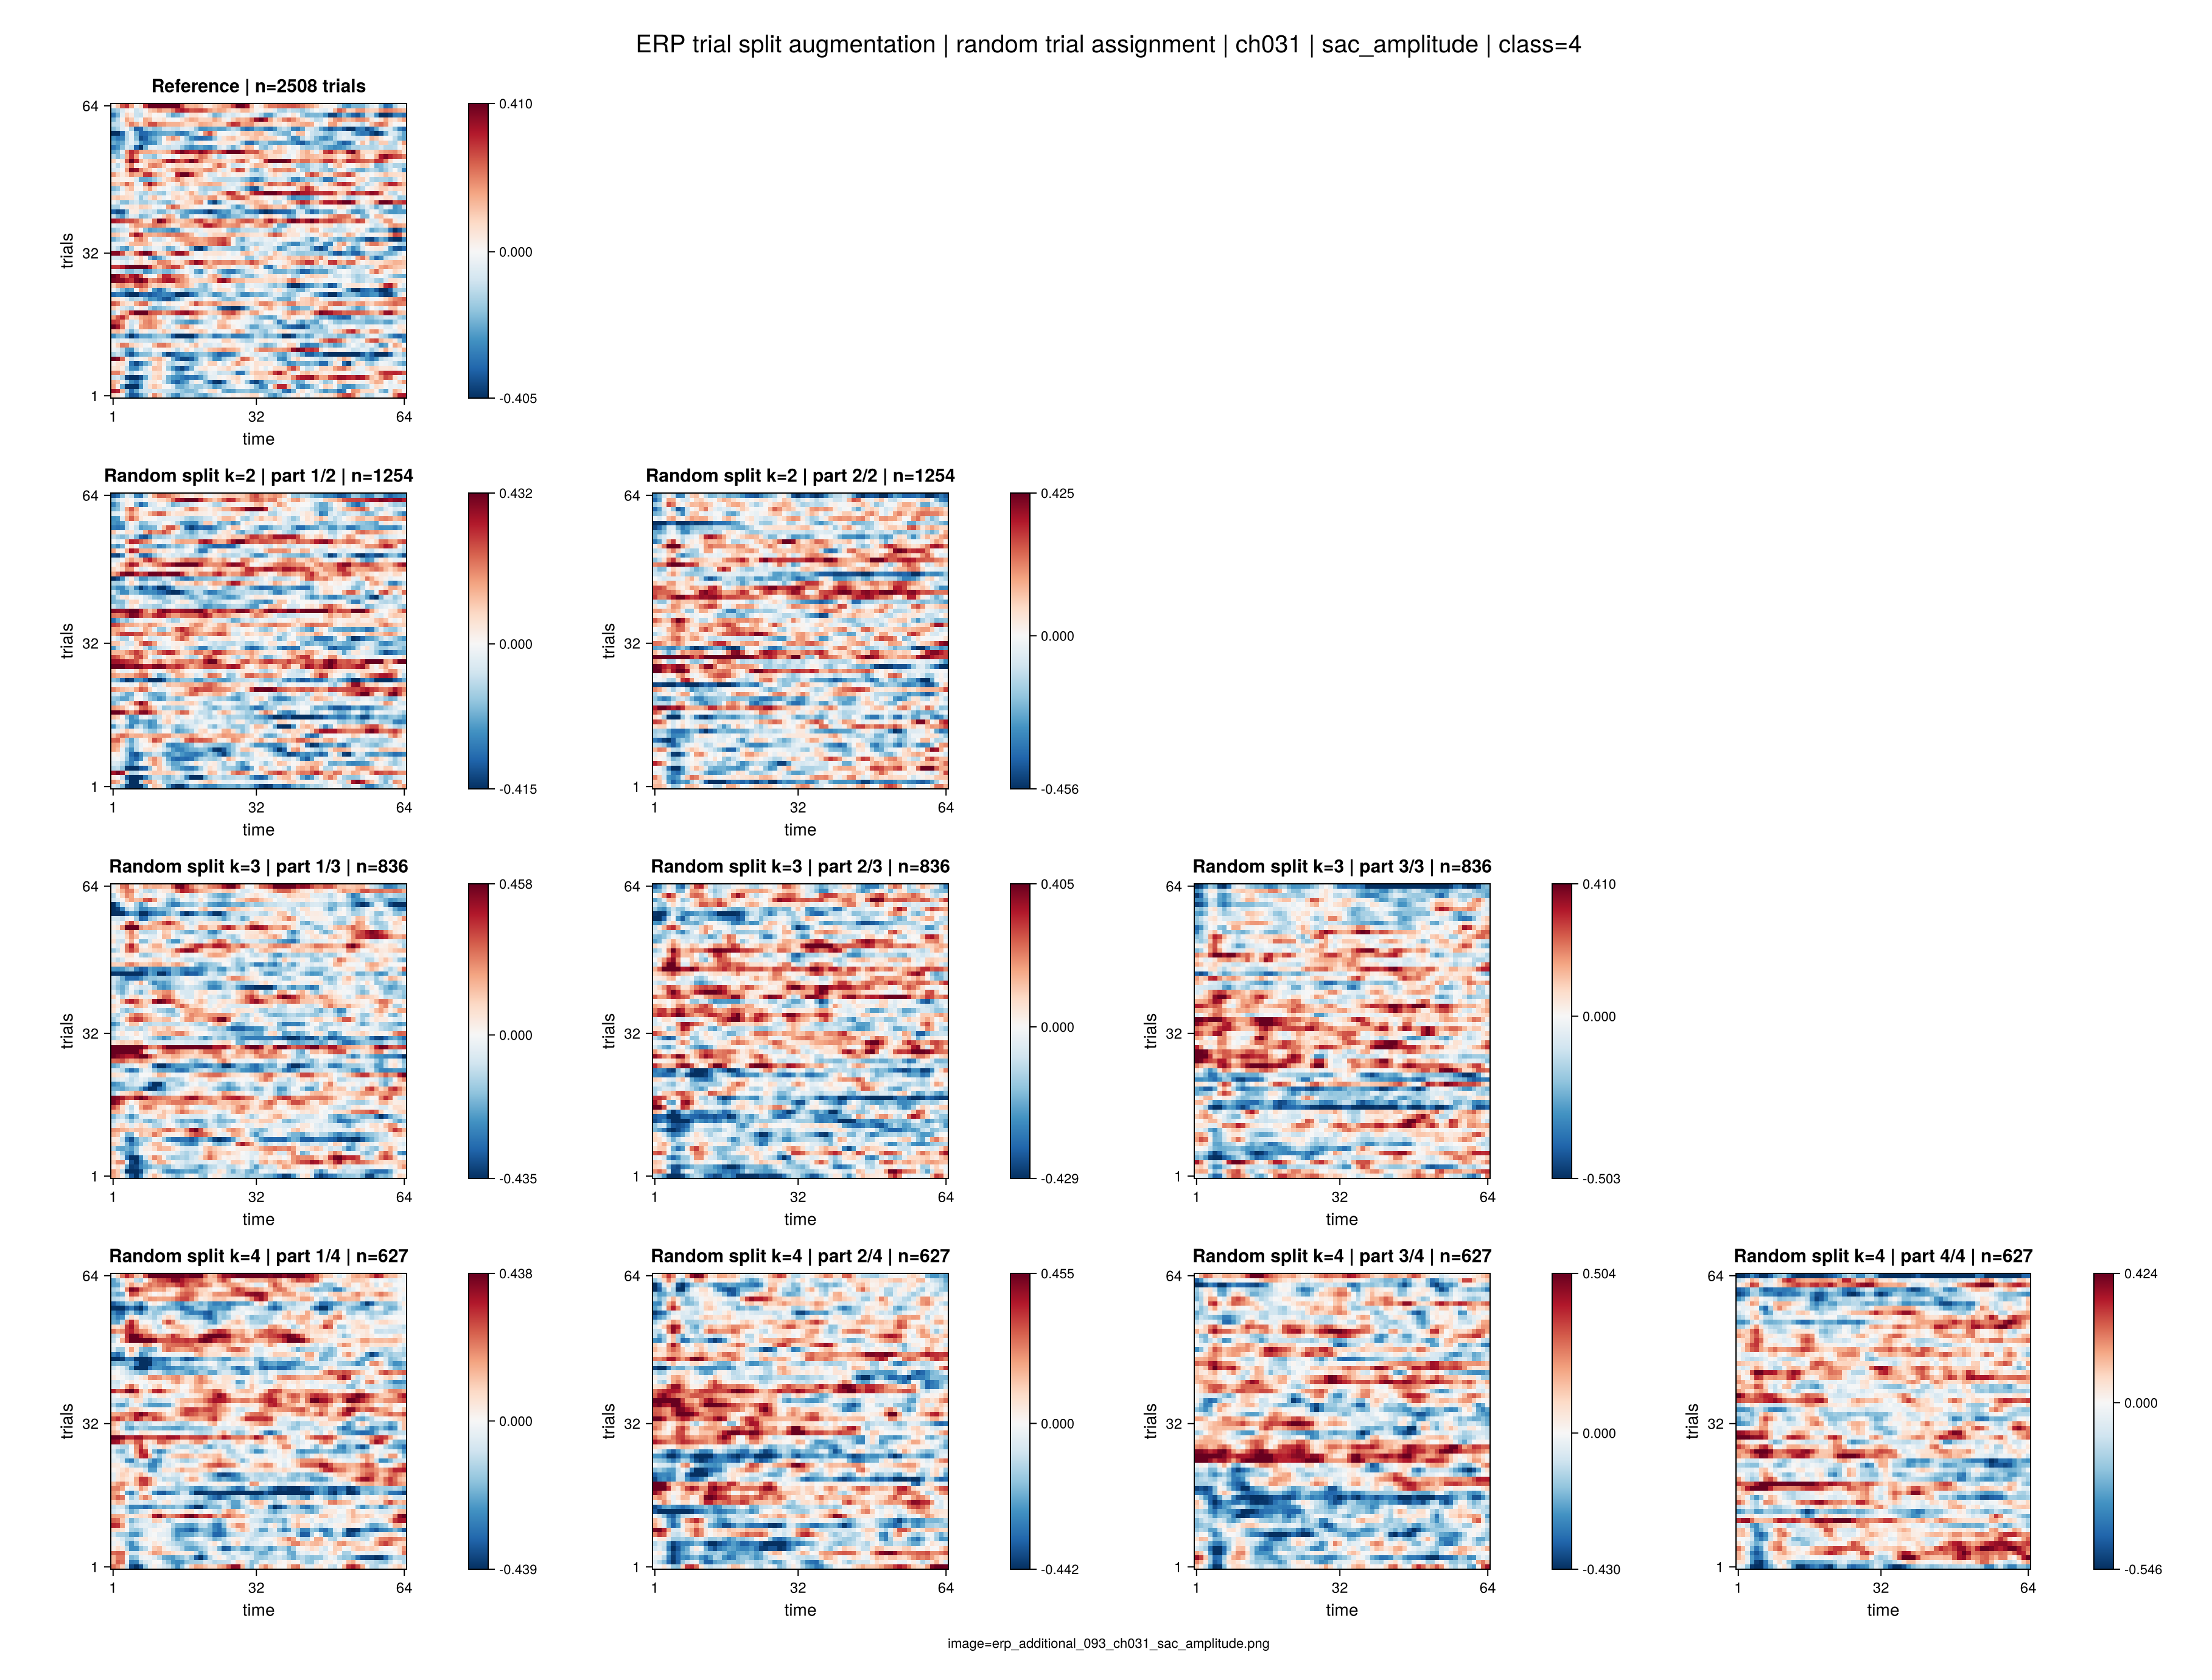

CairoMakie.Screen{IMAGE}


In [5]:
@assert nrow(labels_labeled_df) > 0 "No labeled ERP rows with class > 0 found."

selected_idx = rand(1:nrow(labels_labeled_df))
selected_plot_row = labels_labeled_df[selected_idx, :]

println("Selected example for plotting:")
println("  ch", lpad(string(Int(selected_plot_row.channel_int)), 3, '0'),
        " | ", selected_plot_row.sort_var_symbol,
        " | class=", selected_plot_row.erp_class_id,
        " | ", image_id_from_row(selected_plot_row))

fig_random = plot_trial_split_overview(
    erps,
    events,
    Int(selected_plot_row.channel_int),
    selected_plot_row.sort_var_symbol;
    class_id = Int(selected_plot_row.erp_class_id),
    image_id = image_id_from_row(selected_plot_row),
    split_mode = :random,
    k_values = [2, 3, 4],
    seed = rand(1:10^9),
)
display(fig_random)


## Sorted-Modulo Trial Splits (k = 2, 3, 4)

Trials are first sorted by `sort_variable` and then assigned deterministically by modulo (no randomness).


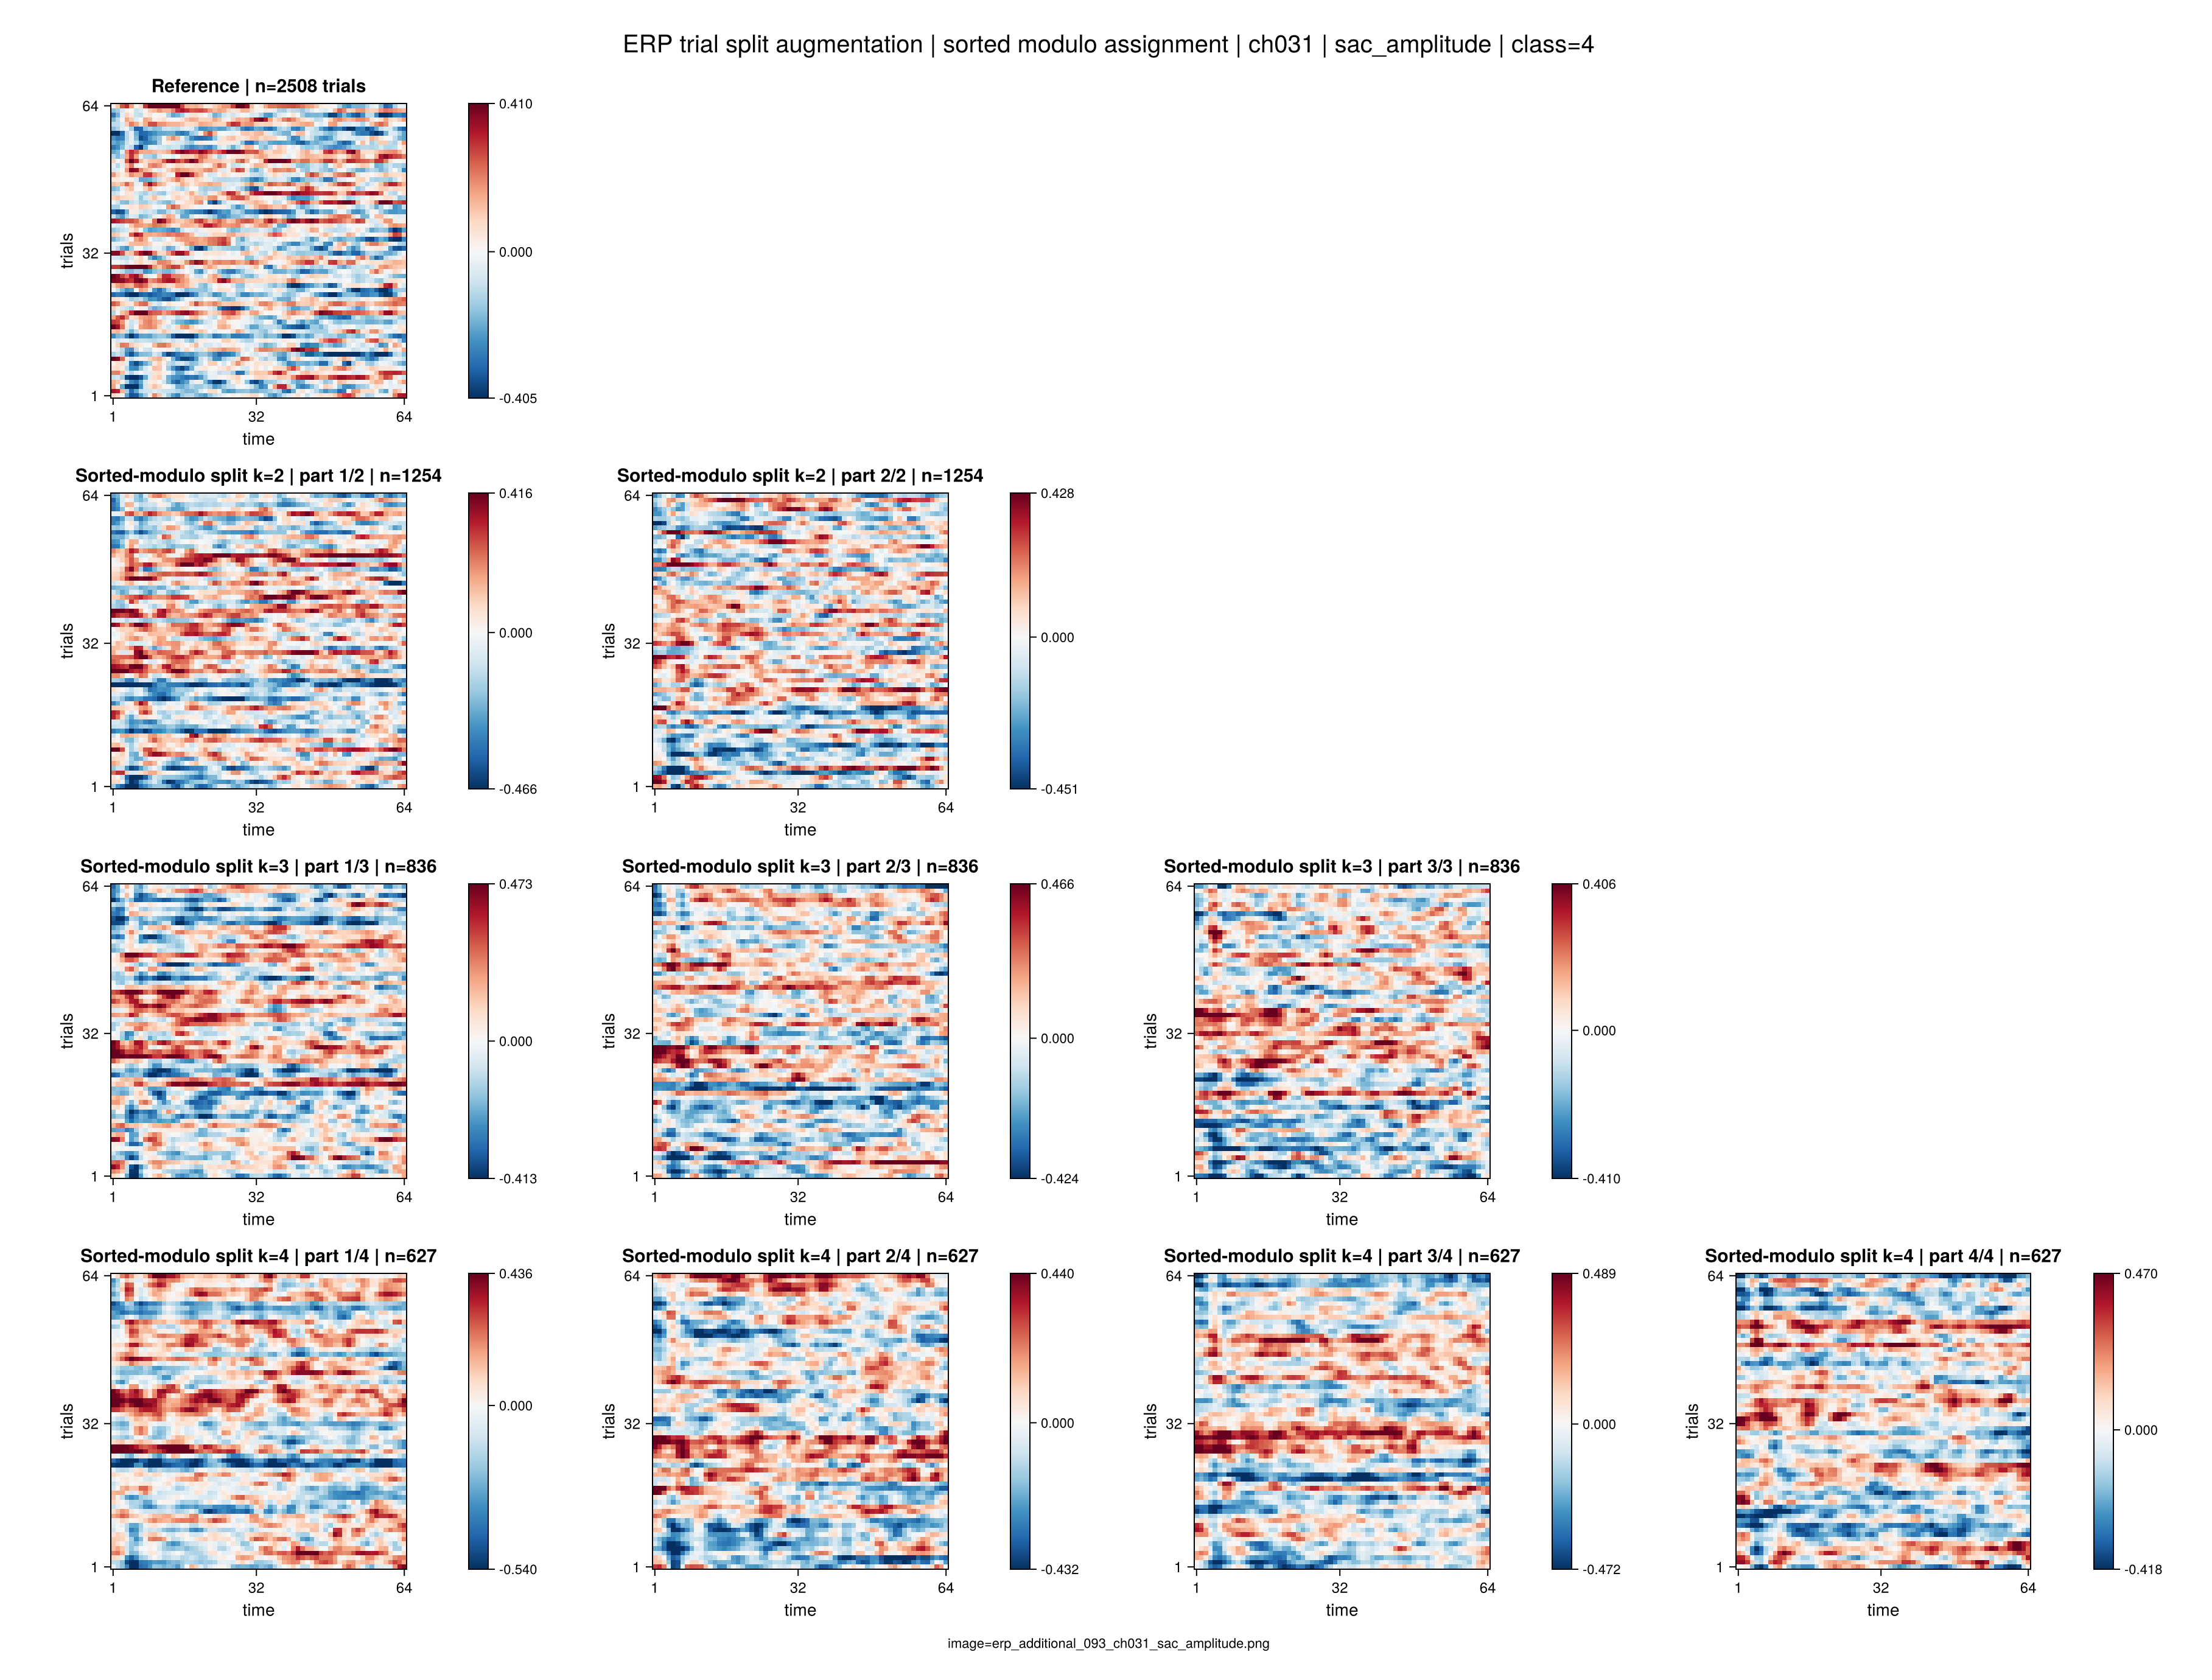

CairoMakie.Screen{IMAGE}


In [6]:
@assert @isdefined(selected_plot_row) "Run the random split selection cell first."

fig_sorted = plot_trial_split_overview(
    erps,
    events,
    Int(selected_plot_row.channel_int),
    selected_plot_row.sort_var_symbol;
    class_id = Int(selected_plot_row.erp_class_id),
    image_id = image_id_from_row(selected_plot_row),
    split_mode = :sorted_modulo,
    k_values = [2, 3, 4],
)
display(fig_sorted)


## Augmentor Operation Comparisons (Before vs After)

This section uses [Augmentor.jl operations](https://evizero.github.io/Augmentor.jl/stable/operations/) and applies each operation
**after sorting + z-score**, but **before low-pass + resize**.

The selected ERP image is still the same single random sample from the earlier selection cell.


Running Augmentor comparisons for one ERP image:
  ch031 | sac_amplitude | class=4 | erp_additional_093_ch031_sac_amplitude.png
Operations: FlipX, Rotate, ShearX, Scale, Resize, Zoom, ElasticDistortion, ColorJitter, GaussianBlur, Crop, CropSize, CropRatio


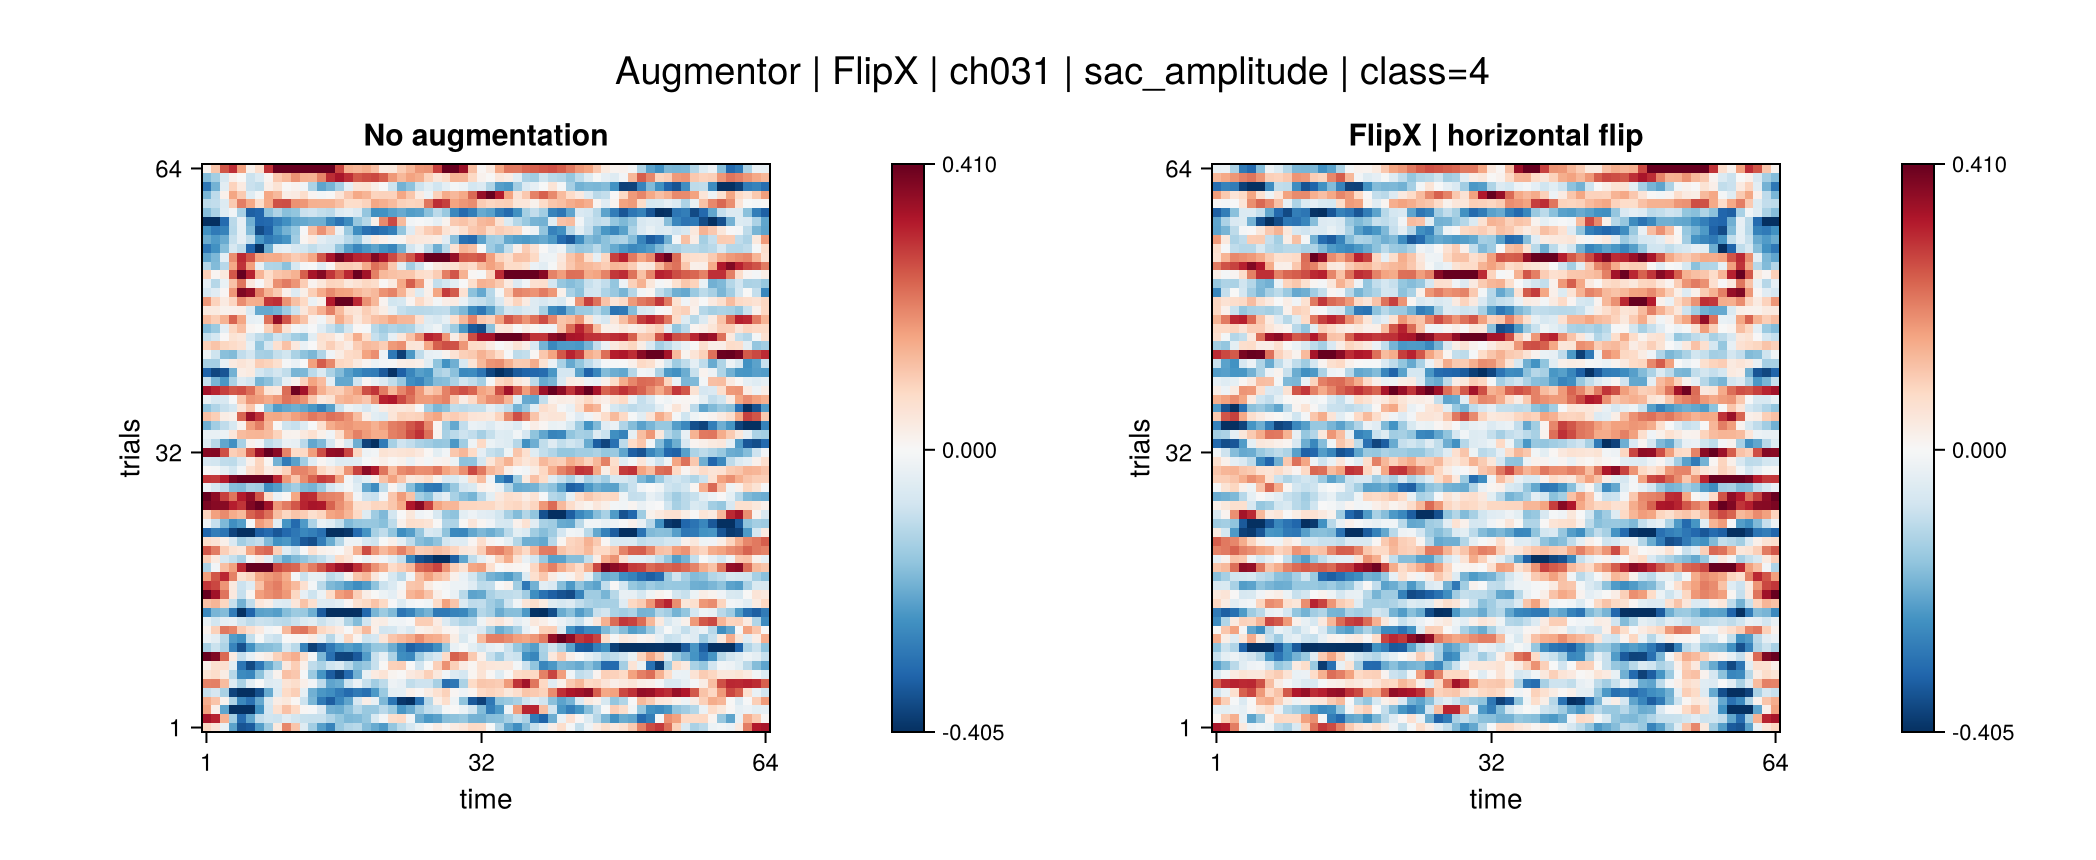

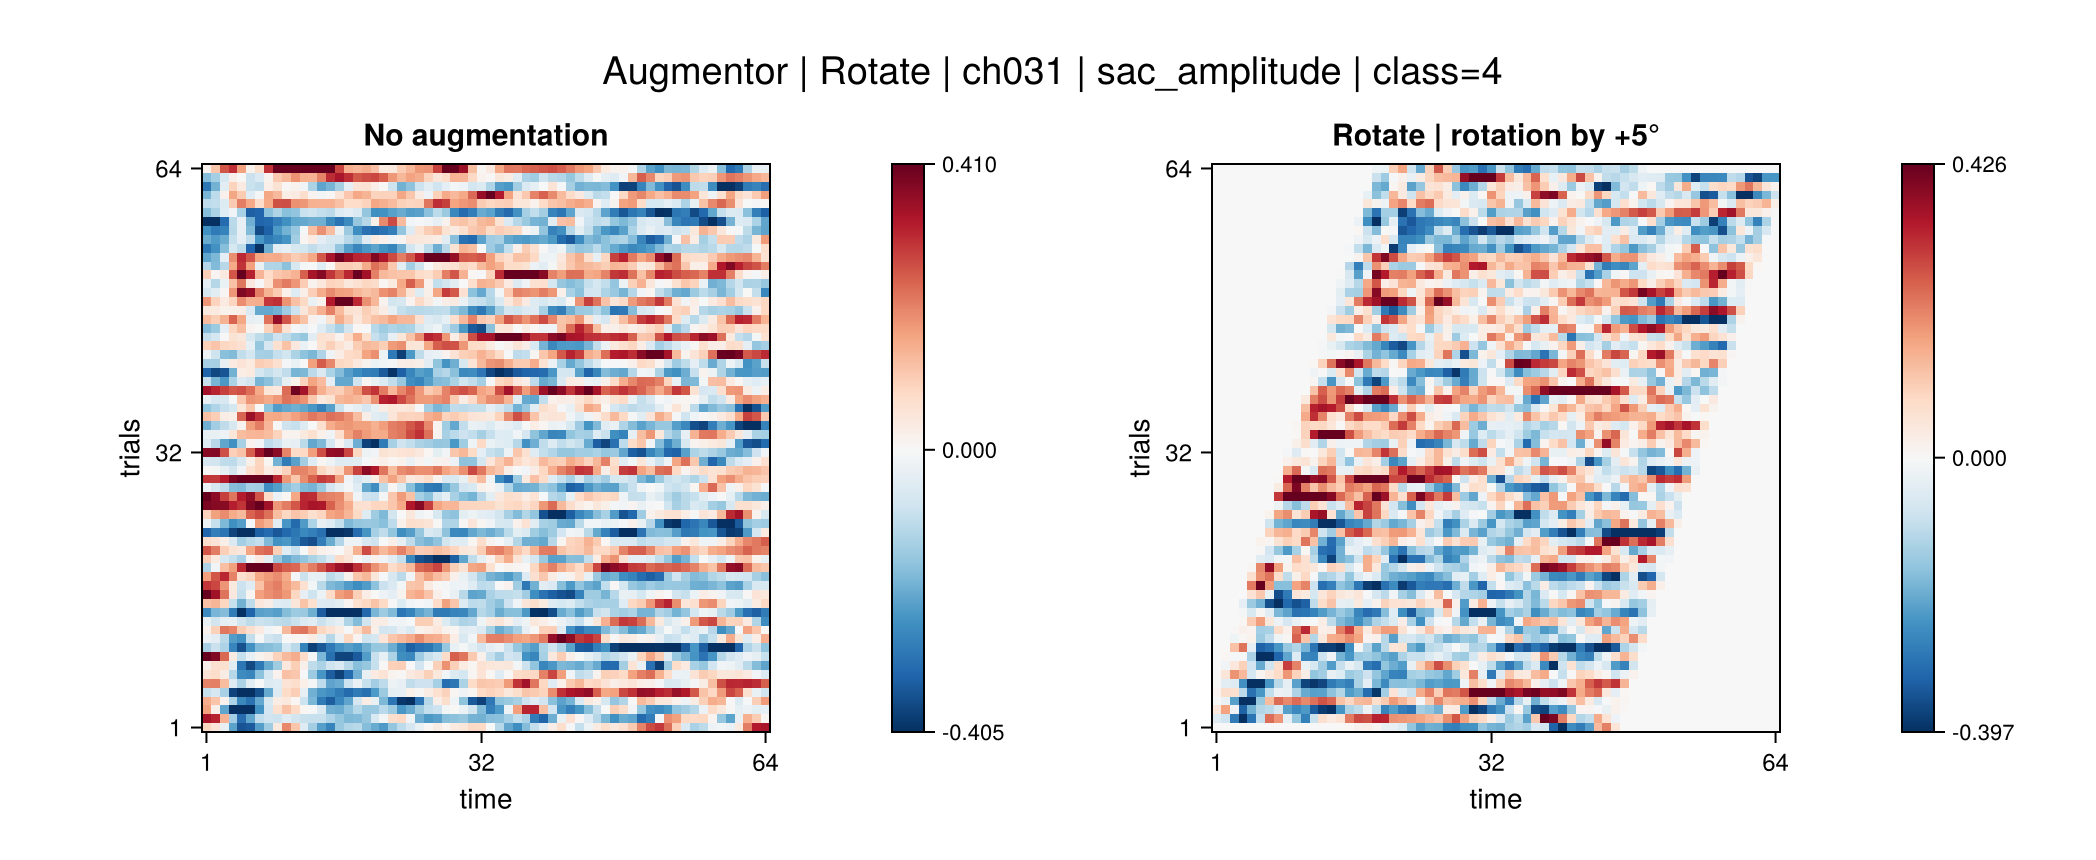

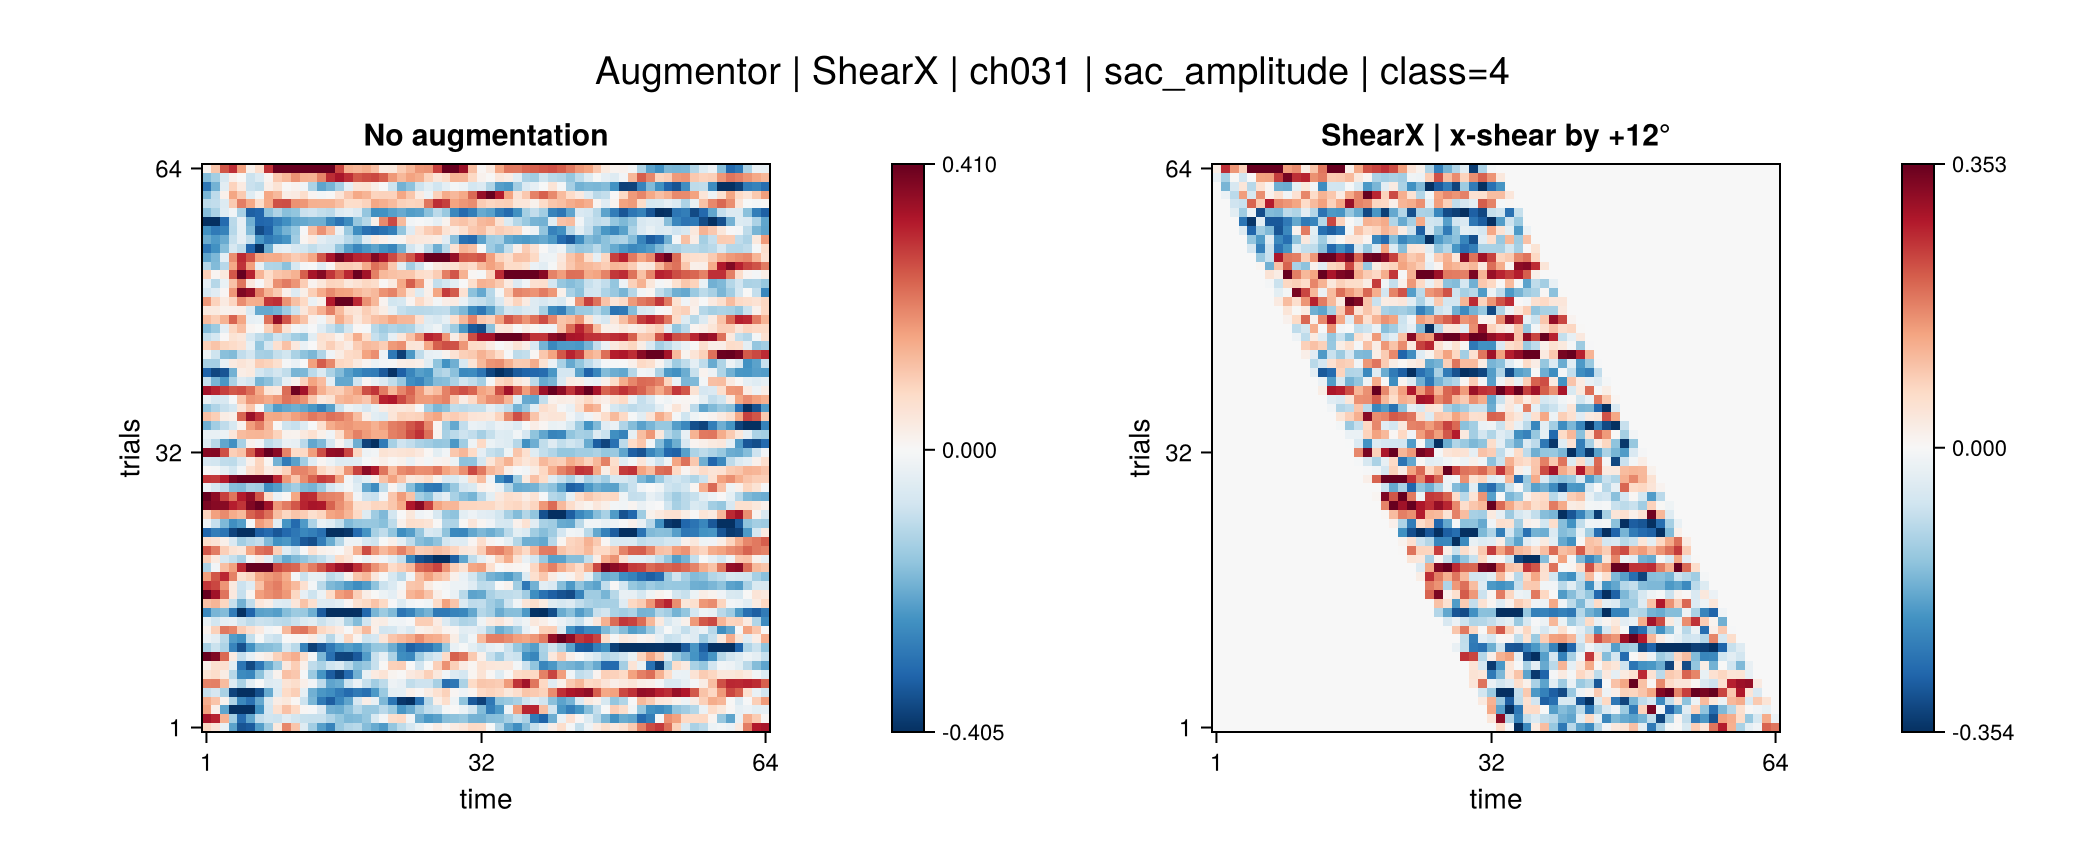

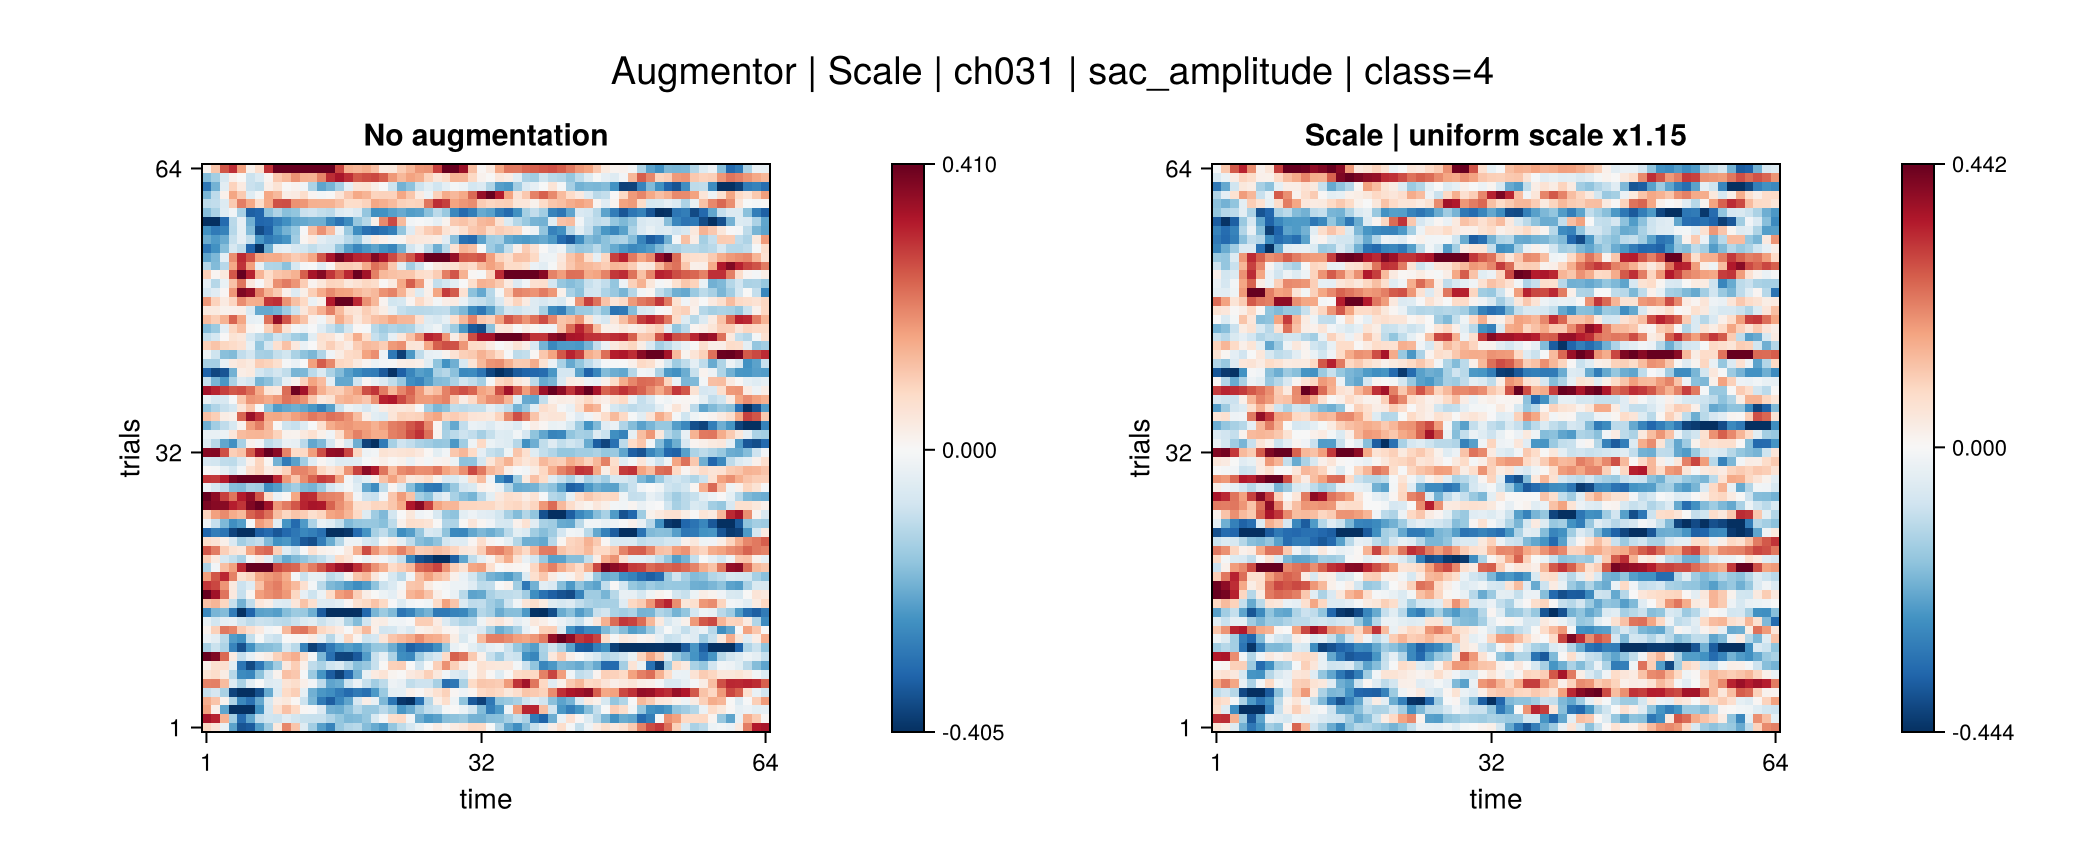

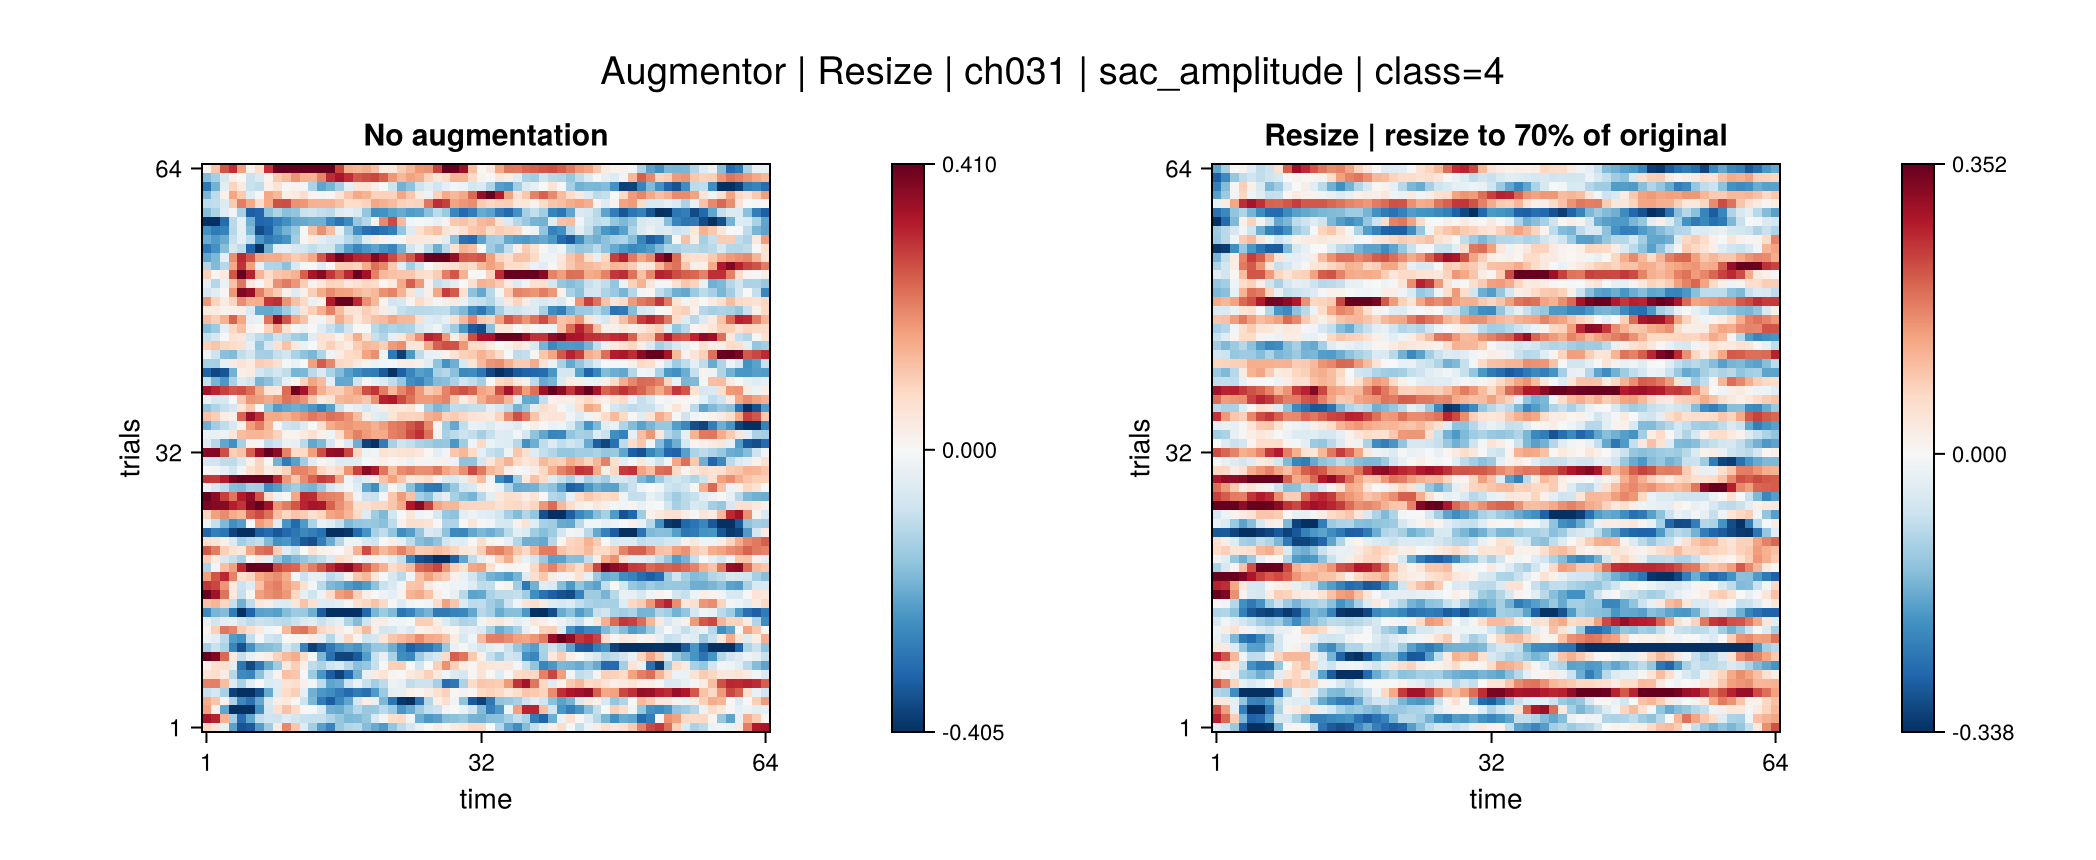

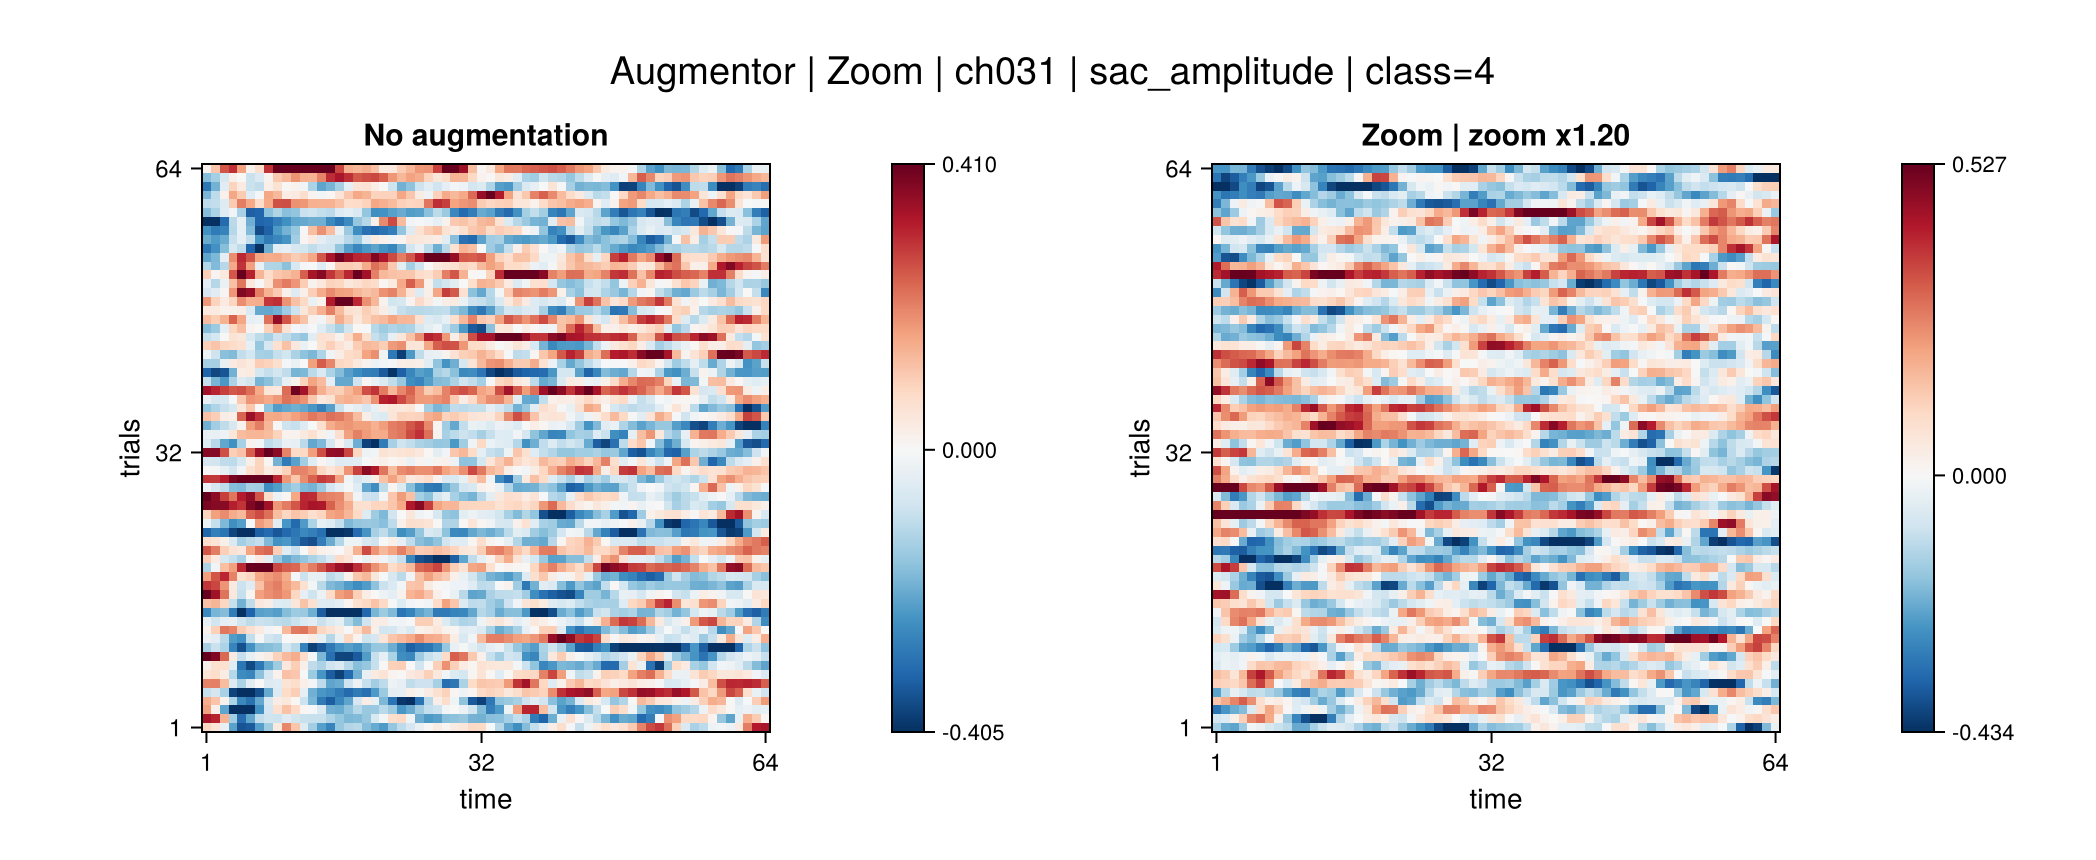

FAILED: ElasticDistortion -> MethodError: no method matching box_extrapolation(::Matrix{Float32}, ::Interpolations.Flat{Nothing})
The function `box_extrapolation` exists, but no method is defined for this comb...


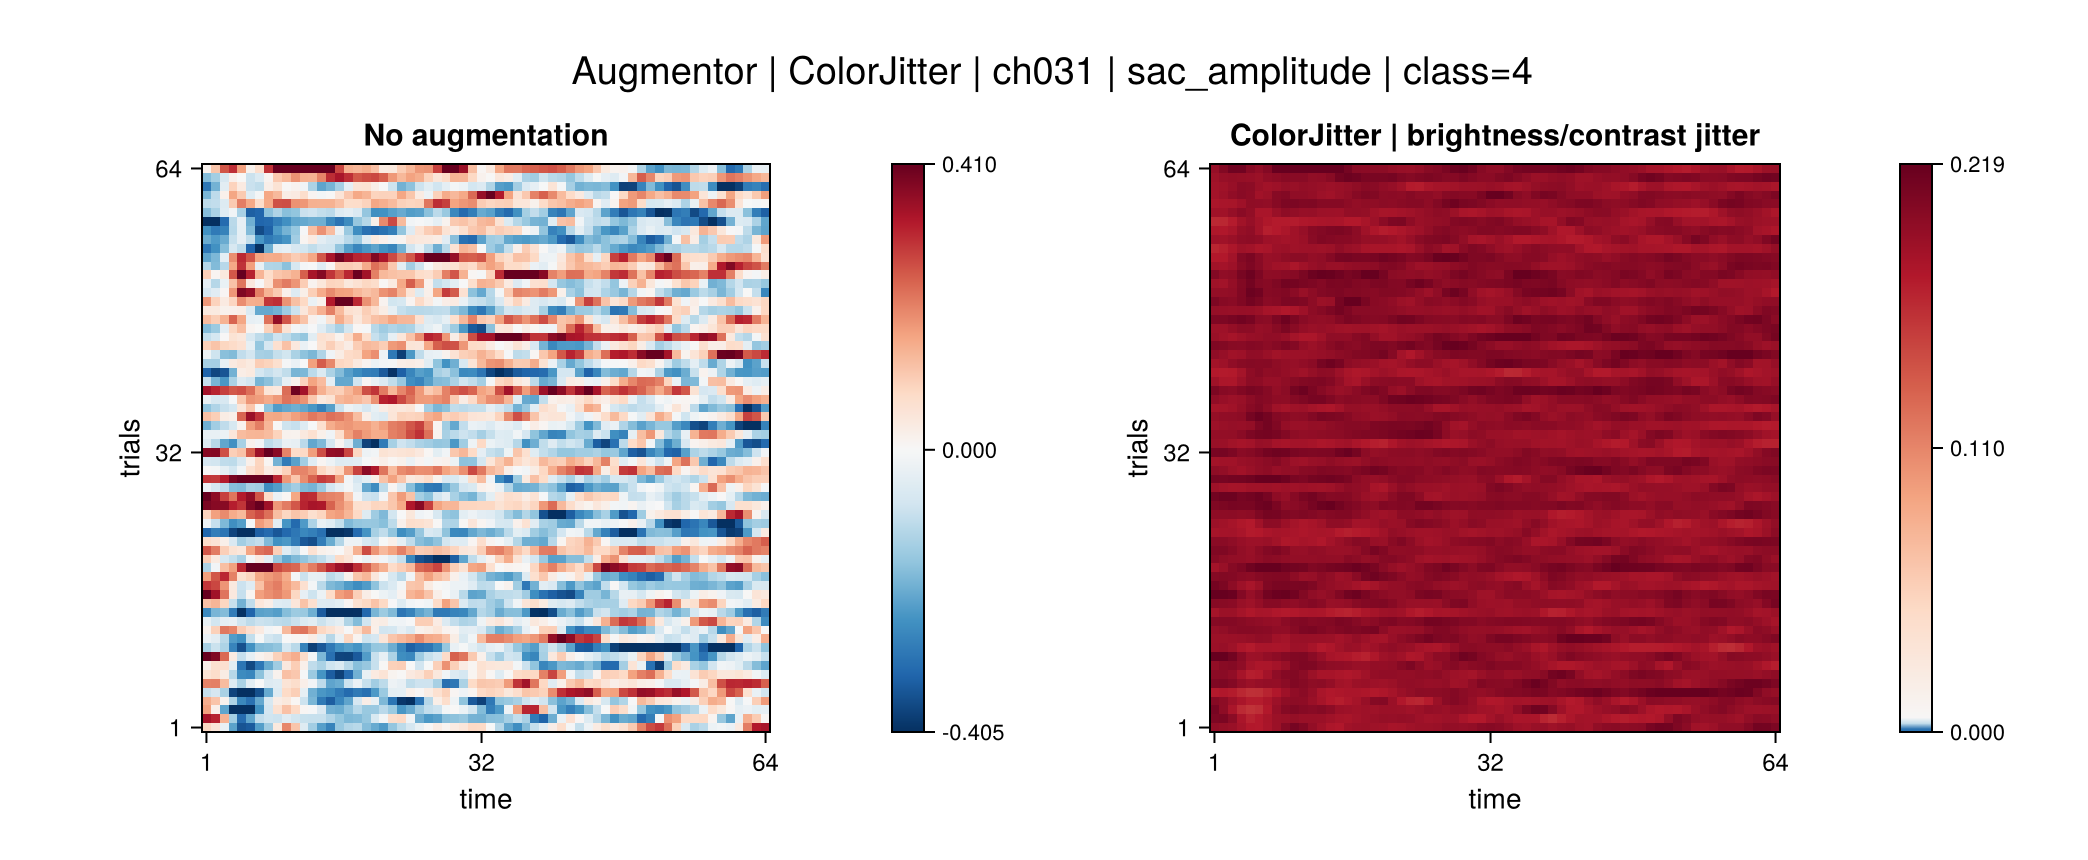

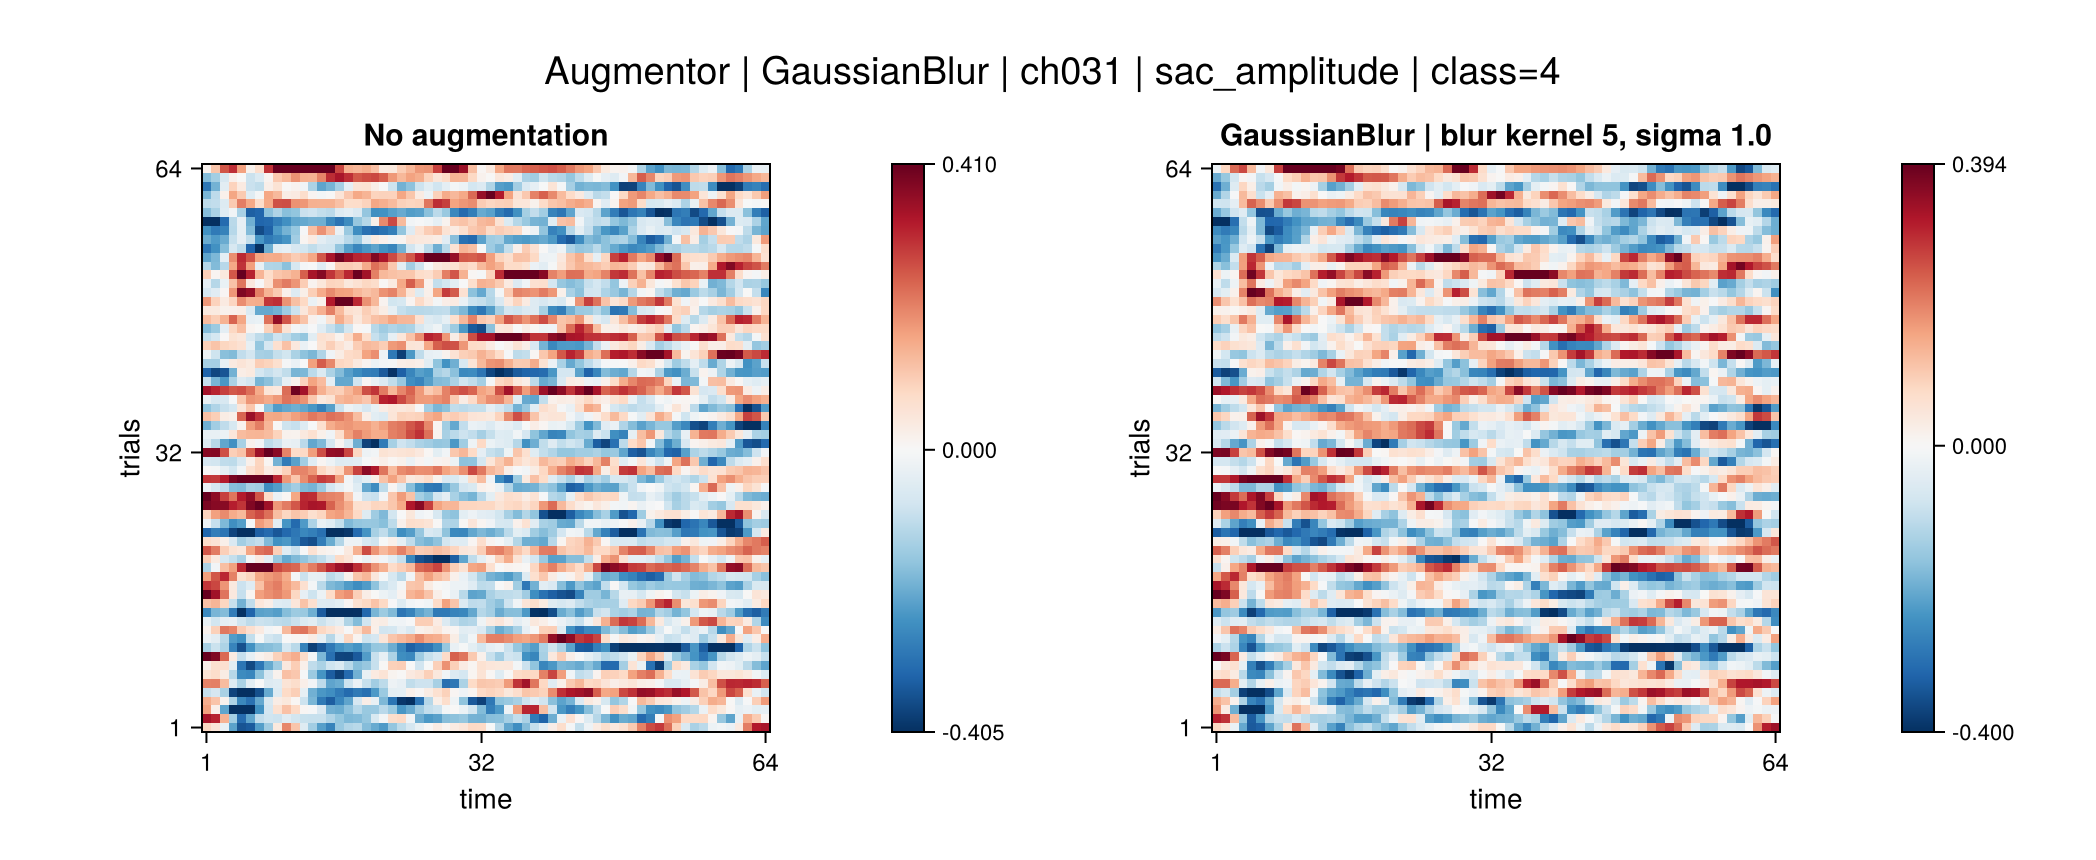

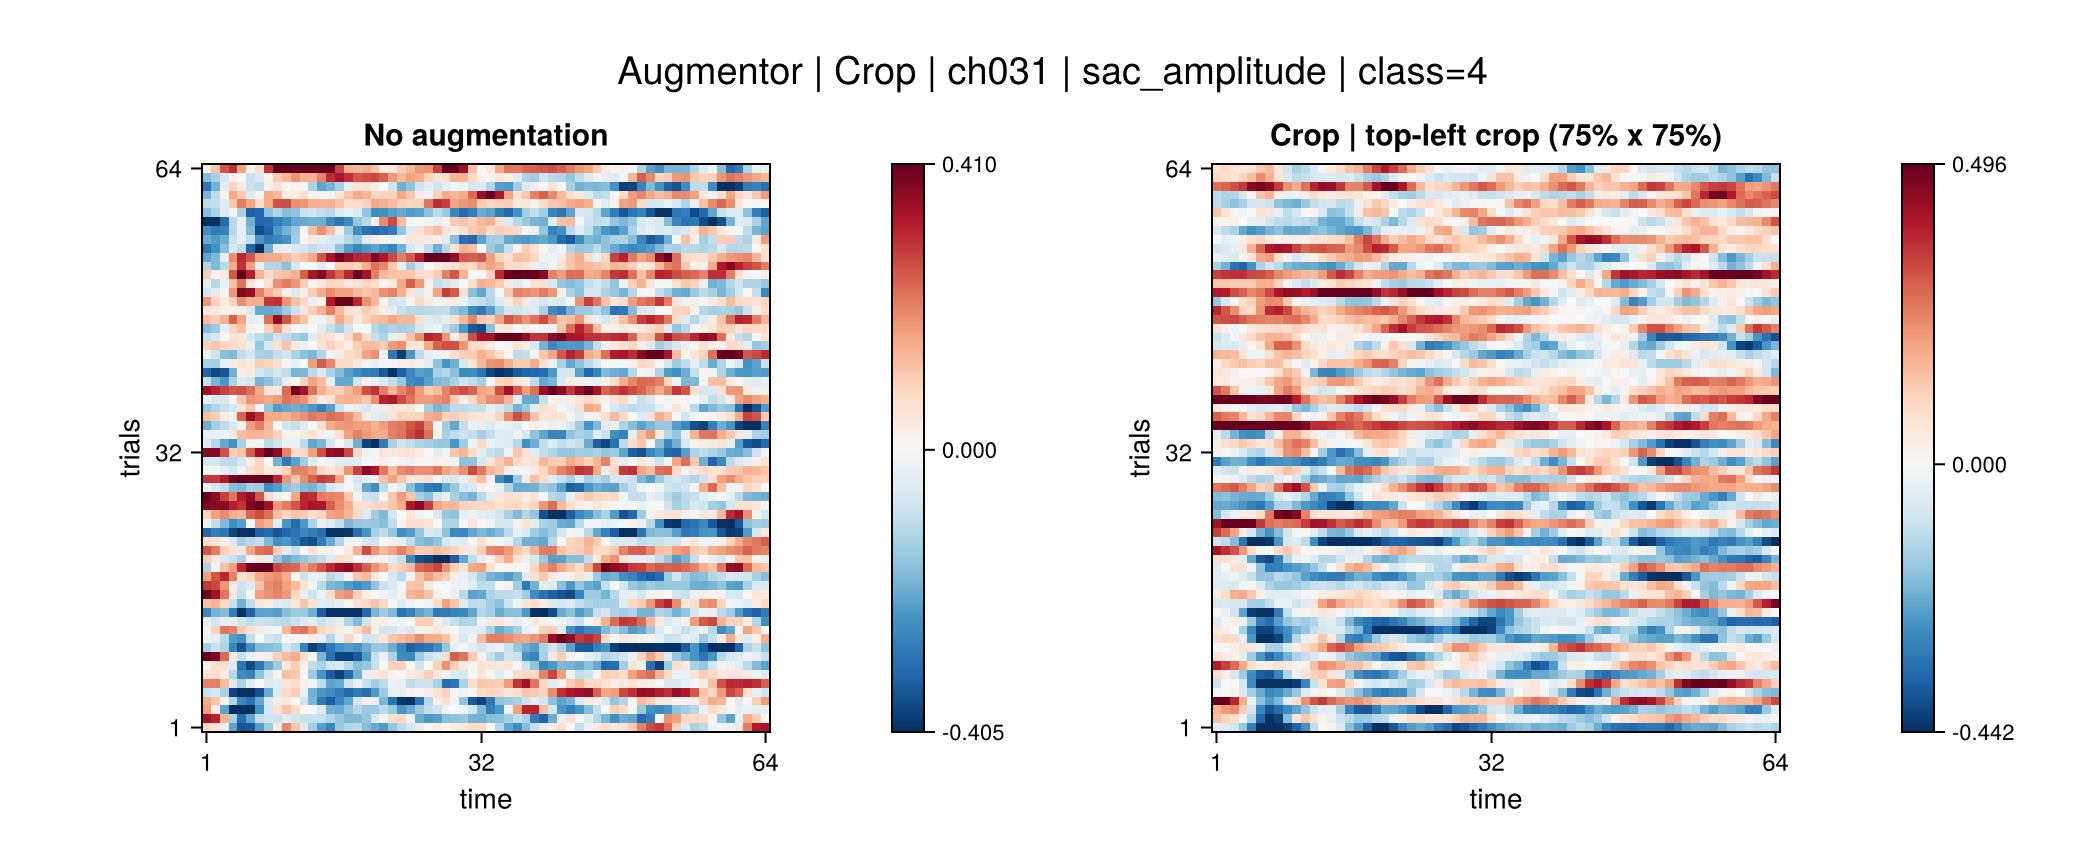

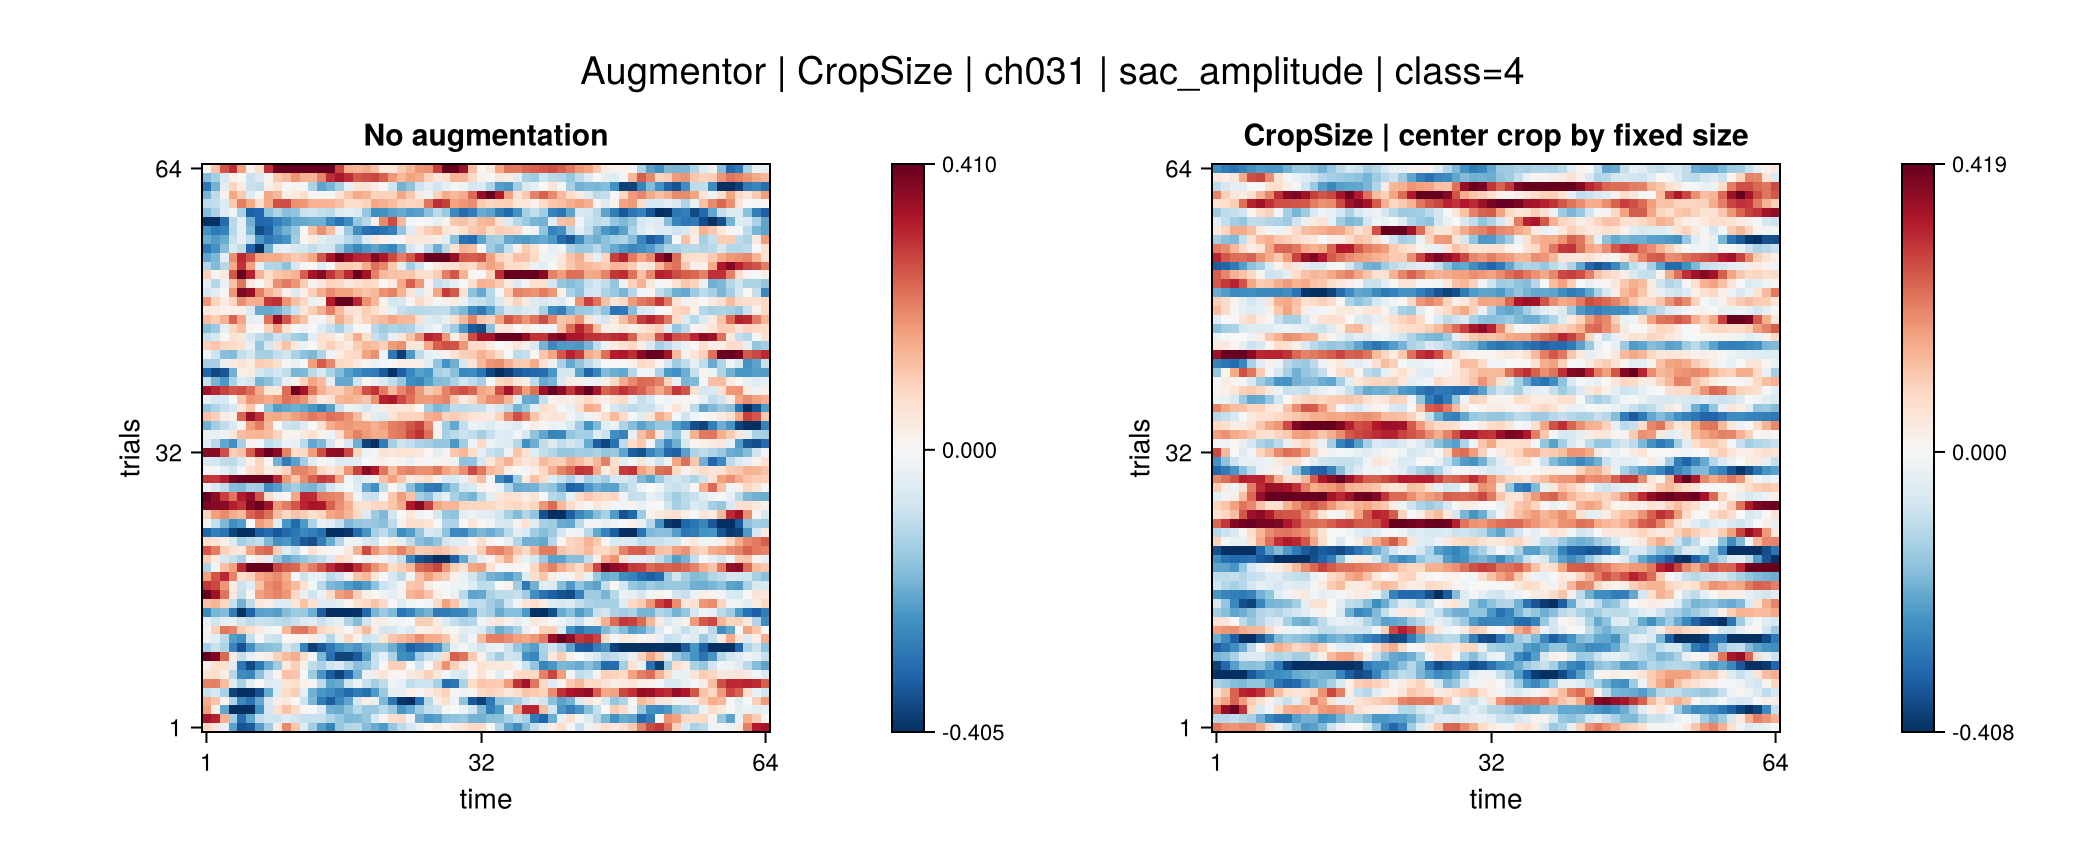

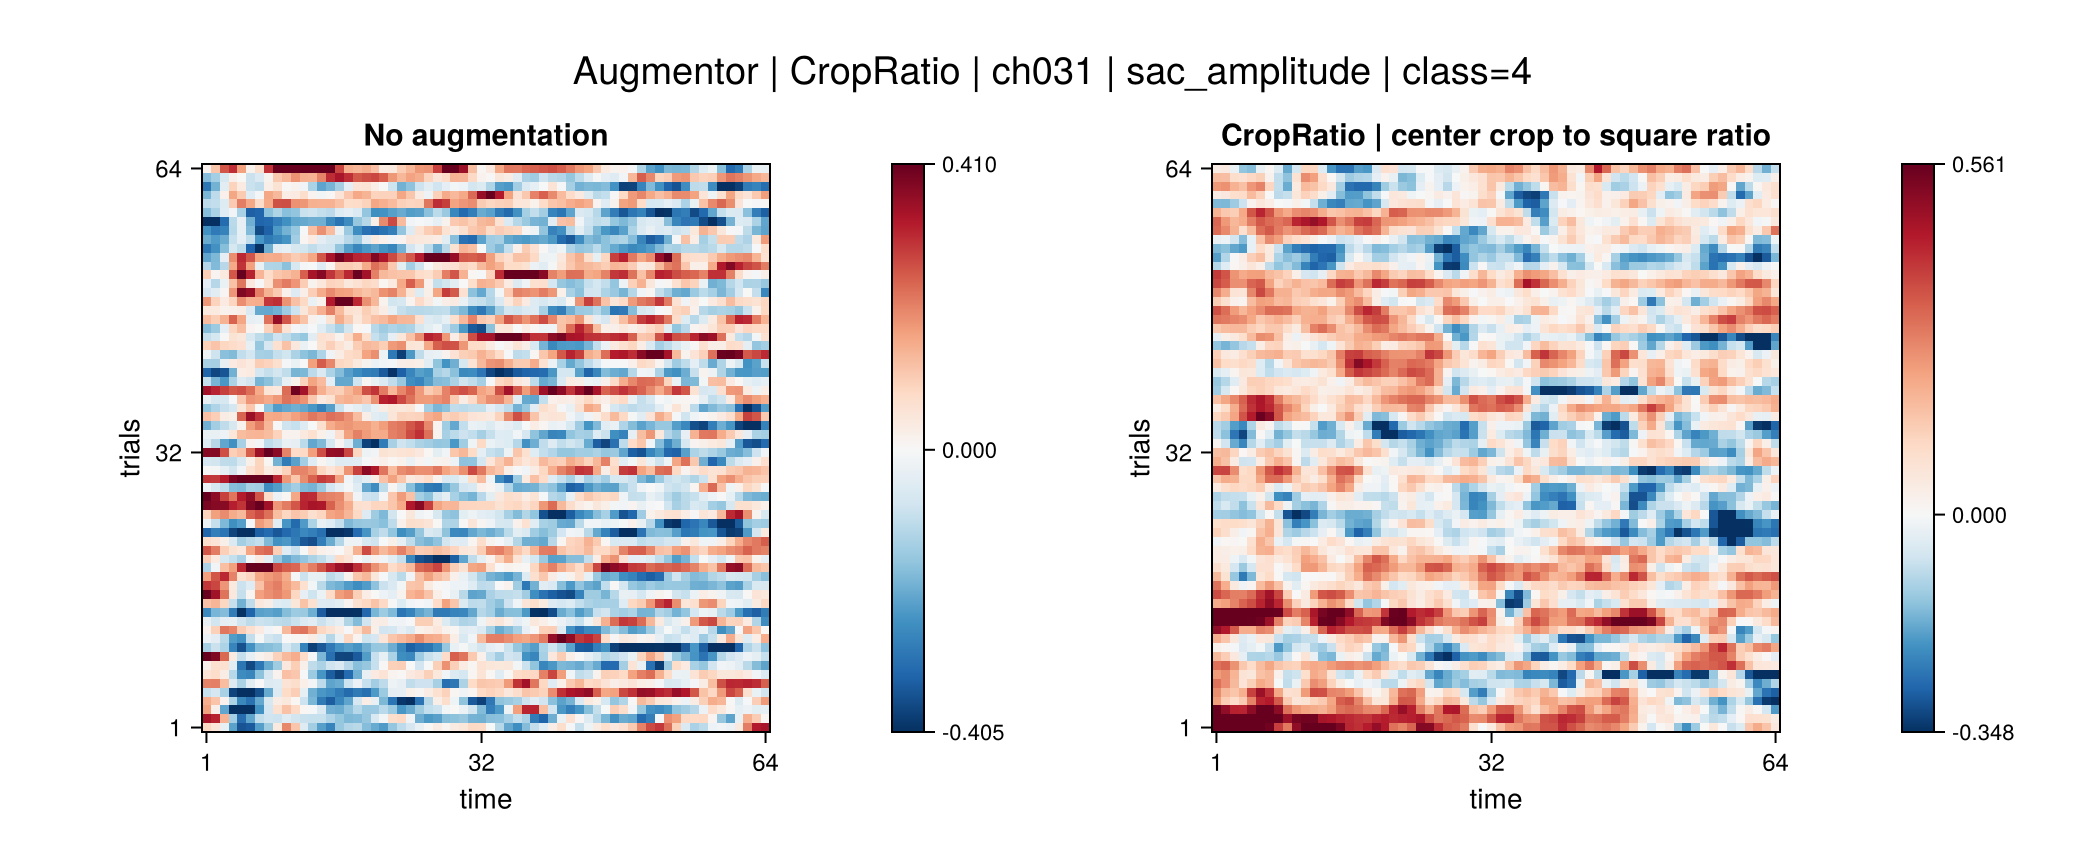


Augmentor run summary:
12×3 DataFrame
 Row │ operation          status  note                              
     │ String             String  String                            
─────┼──────────────────────────────────────────────────────────────
   1 │ FlipX              ok
   2 │ Rotate             ok
   3 │ ShearX             ok
   4 │ Scale              ok
   5 │ Resize             ok
   6 │ Zoom               ok
   7 │ ElasticDistortion  failed  MethodError: no method matching …
   8 │ ColorJitter        ok
   9 │ GaussianBlur       ok
  10 │ Crop               ok
  11 │ CropSize           ok
  12 │ CropRatio          ok


Row,operation,status,note
,String,String,String
1,FlipX,ok,
2,Rotate,ok,
3,ShearX,ok,
4,Scale,ok,
5,Resize,ok,
6,Zoom,ok,
7,ElasticDistortion,failed,"MethodError: no method matching box_extrapolation(::Matrix{Float32}, ::Interpolations.Flat{Nothing})\nThe function `box_extrapolation` exists, but no method is defined for this comb..."
8,ColorJitter,ok,
9,GaussianBlur,ok,


In [9]:
@assert @isdefined(selected_plot_row) "Run the random split selection cell first."

channel = Int(selected_plot_row.channel_int)
sort_col = selected_plot_row.sort_var_symbol
class_id = Int(selected_plot_row.erp_class_id)
image_id = image_id_from_row(selected_plot_row)

data_full, events_full = extract_channel_trials(erps, events, channel)
base_trials_time = sort_zscore_to_trials_time_image(data_full, events_full, sort_col)
base_processed = lowpass_resize_trials_time_image(base_trials_time)

op_specs = build_augmentor_operation_specs(base_trials_time)

println("Running Augmentor comparisons for one ERP image:")
println("  ch", lpad(string(channel), 3, '0'), " | ", sort_col, " | class=", class_id, " | ", image_id)
println("Operations: ", join([op.name for op in op_specs], ", "))

run_rows = NamedTuple[]

for spec in op_specs
    try
        trials_time_aug = apply_augmentor_operation(base_trials_time, spec.name, spec.op)
        processed_aug = lowpass_resize_trials_time_image(trials_time_aug)

        fig = plot_before_after_augmentation(
            base_processed,
            processed_aug;
            header = "Augmentor | $(spec.name) | ch$(lpad(string(channel), 3, '0')) | $(sort_col) | class=$(class_id)",
            right_title = "$(spec.name) | $(spec.description)",
        )
        display(fig)

        push!(run_rows, (operation = spec.name, status = "ok", note = ""))
    catch err
        msg = sprint(showerror, err)
        msg_short = length(msg) > 180 ? msg[1:180] * "..." : msg
        println("FAILED: ", spec.name, " -> ", msg_short)
        push!(run_rows, (operation = spec.name, status = "failed", note = msg_short))
    end
end

augmentor_run_summary_df = DataFrame(run_rows)
println("\nAugmentor run summary:")
show(augmentor_run_summary_df, allrows = true, allcols = true)
println()

augmentor_run_summary_df
